- model loaded


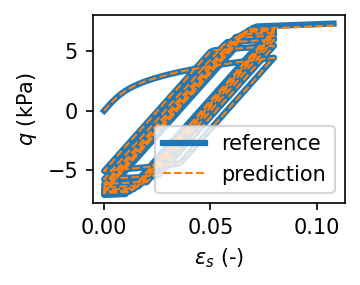

In [36]:
"""Run inference for unseen Drucker–Prager loading protocols."""

import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.utils.parametrize as P
from xitorch.optimize import rootfinder as xiroot

from src.helpers import BatchZOHRate, get_params
from src.input_convex_neural_nets2 import ICNN, PICNN
from src.integrate import integrate_inference, integrate_training
from src.thermodynamics_transport_net import HardThermodynamicsOpNet


# ---------------------------------------------------------------------------
# Reproducibility and file locations
# ---------------------------------------------------------------------------

np.random.seed(1)
torch.manual_seed(1)

# torch.set_num_threads(1)
# torch.set_num_interop_threads(1)

# This must match the precision used to train the checkpoint.
dtype = torch.float32

training_data_path = "./data/elasto_plastic_hardening/training_data.pkl"
inference_data_path = "./data/elasto_plastic_hardening/inference_data.pkl"
results_path = "./checkpoints/elasto_plastic_hardening2.pt"


# ---------------------------------------------------------------------------
# Recover normalization parameters from the training data
# ---------------------------------------------------------------------------

# Only load pickle files obtained from a trusted source.
with open(training_data_path, "rb") as file:
    training_data = pickle.load(file)

(
    training_strain,
    training_strain_tdt,
    training_stress,
    _training_stress_tdt,
    n_training_snapshots,
    _n_training_protocols,
    dim,
) = training_data

if dtype == torch.float32:
    training_strain = np.float32(training_strain)
    training_strain_tdt = np.float32(training_strain_tdt)
    training_stress = np.float32(training_stress)
elif dtype == torch.float64:
    training_strain = np.float64(training_strain)
    training_strain_tdt = np.float64(training_strain_tdt)
    training_stress = np.float64(training_stress)
    
numpy_dtype = np.float64 if dtype == torch.float64 else np.float32

training_strain = training_strain.astype(numpy_dtype, copy=False)
training_strain_tdt = training_strain_tdt.astype(numpy_dtype, copy=False)
training_stress = training_stress.astype(numpy_dtype, copy=False)

# The inference protocols use the same physical time increment as training.
step_size = numpy_dtype(1.0 / n_training_snapshots)

training_strain_rate = np.zeros_like(training_strain)
for i in range(training_strain[:,:,0].shape[1]):
    training_strain_rate[:,i] = np.gradient(training_strain[:,i,0],step_size, edge_order=1)[:,None]


# Reconstruct exactly the normalization used during training.
prm_strain = get_params(training_strain)
prm_strain_rate = get_params(training_strain_rate)
prm_stress = get_params(training_stress)


# ---------------------------------------------------------------------------
# Reconstruct and load the trained model
# ---------------------------------------------------------------------------

dim_hidden = 1
dim_total = dim + dim_hidden

norm_params = [
    prm_strain,
    prm_stress,
    prm_strain_rate,
]

evolution_architecture = [
    dim_total,
    dim_total**2,
    [64, 64, 64, 64],
    "relu",
]

# The partially input-convex network represents the scalar free-energy
# potential as a function of the observable strain and hidden state.
energy_net = PICNN(
    input_x_dim = dim,
    input_y_dim = dim_hidden,
    feature_dim = 32,
    feature_y_dim = 32,
    out_dim = 1,
    num_layers = 3,
    act = "elu",
    act_v = "elu",
    dtype=dtype,
)

model = HardThermodynamicsOpNet(
    evolution_architecture,
    energy_net,
    norm_params,
    dim,
    dim_hidden,
    dtype=dtype,
)

# Recreate the training-time interpolation module before loading the checkpoint.
# Its registered tensors are included in the saved state_dict.
training_time_grid = torch.arange(0, 1.0, step_size)

model.step_size = step_size
model.rate_interp = BatchZOHRate(
    training_time_grid,
    training_strain_rate,
    dtype=dtype,
)

model.norm_init_cond = torch.nn.Parameter(
    torch.zeros((1, dim), dtype=dtype),
    requires_grad=True,
)

state_dict = torch.load(
    results_path,
    map_location="cpu",
    weights_only=True,
)
model.load_state_dict(state_dict, strict=True)
model.eval()

# The reference energy gradients are not stored in the checkpoint and therefore
# must be reconstructed from the first training snapshot.
training_strain_tensor = torch.from_numpy(training_strain)

with P.cached():
    model.ref_grads = model.reference_grads(
        training_strain_tensor[0]
    )

print("- model loaded")


# ---------------------------------------------------------------------------
# Determine elastic strain from the prescribed initial stress
# ---------------------------------------------------------------------------

def initial_condition_residual(
    normalized_elastic_strain,
    svars,
    target_stress,
):
    """Return the normalized error in the reconstructed initial stress."""

    # Stress evaluation differentiates the energy with respect to strain.
    normalized_elastic_strain.requires_grad_()

    elastic_strain = model.DeNormalize(
        normalized_elastic_strain,
        model.prm_strain,
    )
    predicted_stress = model.compute_stress(torch.cat((elastic_strain, svars),axis=-1), return_all=False)

    normalized_predicted_stress = model.Normalize(
        predicted_stress,
        model.prm_stress,
    )

    normalized_target_stress = model.Normalize(
        target_stress,
        model.prm_stress,
    )
    return normalized_predicted_stress - normalized_target_stress


# ---------------------------------------------------------------------------
# Load and preprocess the unseen loading protocols
# ---------------------------------------------------------------------------

with open(inference_data_path, "rb") as file:
    inference_data = pickle.load(file)

(
    inference_strain,
    inference_strain_tdt,
    inference_stress,
    _inference_stress_tdt,
    n_inference_snapshots,
    n_inference_protocols,
    inference_dim,
) = inference_data

if dtype == torch.float32:
    inference_strain = np.float32(inference_strain)
    inference_strain_tdt = np.float32(inference_strain_tdt)
    inference_stress = np.float32(inference_stress)
elif dtype == torch.float64:
    inference_strain = np.float64(inference_strain)
    inference_strain_tdt = np.float64(inference_strain_tdt)
    inference_stress = np.float64(inference_stress)


if inference_dim != dim:
    raise ValueError(
        "The inference and training data have incompatible dimensions: "
        f"{inference_dim} and {dim}."
    )

inference_strain = inference_strain.astype(
    numpy_dtype,
    copy=False,
)
inference_strain_tdt = inference_strain_tdt.astype(
    numpy_dtype,
    copy=False,
)
inference_stress = inference_stress.astype(
    numpy_dtype,
    copy=False,
)

# inference_strain_rate = (
#     inference_strain_tdt - inference_strain
# ) / step_size

inference_strain_rate = np.zeros_like(inference_strain)
for i in range(inference_strain[:,:,0].shape[1]):
    inference_strain_rate[:,i] = np.gradient(inference_strain[:,i,0],step_size, edge_order=1)[:,None]


inference_strain_tensor = torch.from_numpy(inference_strain)
inference_stress_tensor = torch.from_numpy(inference_stress)

protocol_indices = np.arange(n_inference_protocols)

# Construct exactly one time value per inference snapshot. This avoids possible
# off-by-one errors caused by floating-point use of torch.arange(start, stop, dt).
time_grid = (
    torch.arange(n_inference_snapshots, dtype=dtype)
    * step_size
)

model.step_size = step_size
model.rate_interp = BatchZOHRate(
    time_grid,
    inference_strain_rate,
    dtype=dtype,
)


# ---------------------------------------------------------------------------
# Reconstruct the initial state
# ---------------------------------------------------------------------------

initial_stress = inference_stress_tensor[0]
initial_svars = torch.zeros((initial_stress.shape[1],dim_hidden),dtype=dtype)

# Start the nonlinear solve from zero normalized elastic strain.
initial_guess = torch.zeros_like(
    initial_stress,
    requires_grad=True,
)

normalized_initial_strain = xiroot(
    initial_condition_residual,
    initial_guess,
    params=(initial_svars,initial_stress,),
    method="newton",
    maxiter=1_000,
    step=2.0e-2,
    verbose=True,
)

initial_strain = model.DeNormalize(
    normalized_initial_strain,
    model.prm_strain,
)

initial_conditions = torch.cat((initial_strain, initial_svars),axis=-1)
# ---------------------------------------------------------------------------
# Integrate the inferred stress response
# ---------------------------------------------------------------------------

with P.cached():
    state_solution, stress_solution = integrate_training(
            model,
            initial_conditions,
            time_grid,
            protocol_indices,
        )
    # state_solution, stress_solution, solver_info = integrate_inference(
    #     model=model,
    #     initial_conditions=initial_conditions,
    #     t_eval=time_grid,
    #     idx=protocol_indices,
    #     initial_step=step_size,
    #     minimum_step=1.0e-8,
    #     maximum_step=step_size,
    #     relative_tolerance=1.0e-3,
    #     absolute_tolerance=1.0e-4,
    # )


# ---------------------------------------------------------------------------
# Compare the reference and predicted responses
# ---------------------------------------------------------------------------

protocol = 0
component = 0 

strain_to_plot = (
    inference_strain_tensor[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)
reference_stress = (
    inference_stress_tensor[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)
predicted_stress = (
    stress_solution[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)

fig, ax = plt.subplots(
    dpi=150,
    figsize=(2.5, 2),
)

ax.plot(
    strain_to_plot,
    reference_stress,
    linewidth=3,
    label="reference",
)
ax.plot(
    strain_to_plot,
    predicted_stress,
    linewidth=1,
    linestyle="--",
    label="prediction",
)

ax.set_xlabel(r"$\varepsilon_s$ (-)")
ax.set_ylabel(r"$q$ (kPa)")
ax.legend(loc="best")

fig.tight_layout()
plt.show()

In [28]:
with P.cached():
    # state_solution, stress_solution = integrate_training(
    #         model,
    #         initial_conditions,
    #         time_grid,
    #         protocol_indices,
    #     )
    state_solution, stress_solution, solver_info = integrate_inference(
        model=model,
        initial_conditions=initial_conditions,
        t_eval=time_grid,
        idx=protocol_indices,
        initial_step=step_size,
        minimum_step=1.0e-8,
        maximum_step=step_size,
        relative_tolerance=1.0e-3,
        absolute_tolerance=1.0e-4,
    )
solver_info

{'accepted_steps': 2673,
 'rejected_steps': 17,
 'rhs_evaluations': 5380,
 'accepted_times': tensor([0.0000, 0.0038, 0.0077,  ..., 2.3580, 2.3591, 2.3615]),
 'accepted_step_sizes': tensor([0.0038, 0.0038, 0.0038,  ..., 0.0002, 0.0011, 0.0024]),
 'accepted_error_norms': tensor([3.4829e-01, 2.8041e-01, 2.6307e-01,  ..., 5.6975e-06, 1.1673e-04,
         1.4418e-03])}

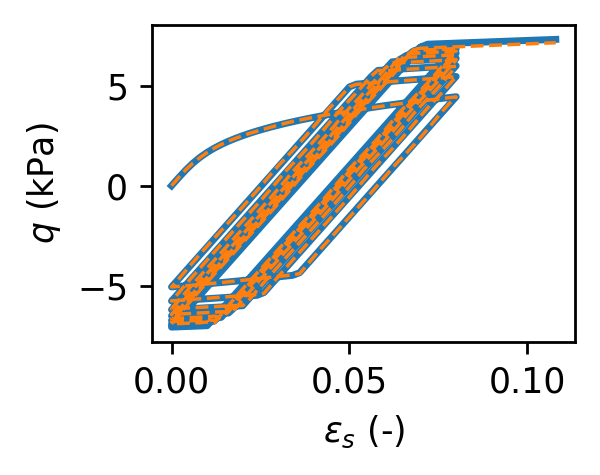

In [37]:
protocol = 0
component = 0  # Deviatoric strain ε_s and stress q.

strain_to_plot = (
    inference_strain_tensor[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)
reference_stress = (
    inference_stress_tensor[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)
predicted_stress = (
    stress_solution[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)

fig, ax = plt.subplots(
    dpi=250,
    figsize=(2.5, 2),
)

ax.plot(
    strain_to_plot,
    reference_stress,
    linewidth=2,
    label="reference",
)
ax.plot(
    strain_to_plot,
    predicted_stress,
    linewidth=1,
    linestyle="--",
    label="prediction",
)

ax.set_xlabel(r"$\varepsilon_s$ (-)")
ax.set_ylabel(r"$q$ (kPa)")
# ax.legend(loc="best")
# ax.set_xlim(0,0.2)
fig.tight_layout()
plt.show()

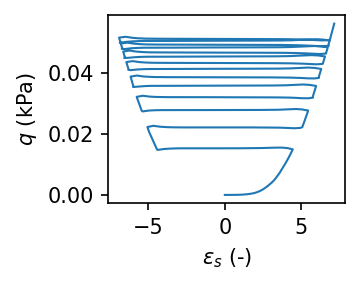

In [38]:
protocol = 0
component = 0  # Deviatoric strain ε_s and stress q.

strain_to_plot = (
    inference_strain_tensor[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)
reference_stress = (
    inference_stress_tensor[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)
predicted_svars = (
    state_solution[:, protocol, -1]
    .detach()
    .cpu()
    .numpy()
)

fig, ax = plt.subplots(
    dpi=150,
    figsize=(2.5, 2),
)

# ax.plot(
#     strain_to_plot,
#     reference_stress,
#     linewidth=3,
#     label="reference",
# )
ax.plot(
    predicted_stress,
    predicted_svars,
    linewidth=1,
    linestyle="-",
    label="prediction",
)

ax.set_xlabel(r"$\varepsilon_s$ (-)")
ax.set_ylabel(r"$q$ (kPa)")
# ax.legend(loc="best")
# ax.set_xlim(0,0.2)
fig.tight_layout()
plt.show()

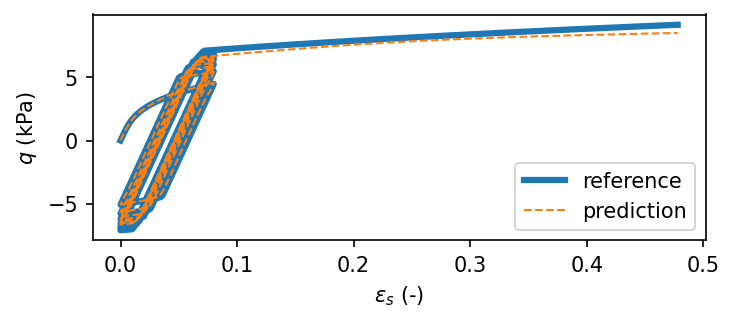

In [23]:
protocol = 0
component = 0  # Deviatoric strain ε_s and stress q.

strain_to_plot = (
    inference_strain_tensor[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)
reference_stress = (
    inference_stress_tensor[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)
predicted_stress = (
    stress_solution[:, protocol, component]
    .detach()
    .cpu()
    .numpy()
)

fig, ax = plt.subplots(
    dpi=150,
    figsize=(5, 2.25),
)

ax.plot(
    strain_to_plot,
    reference_stress,
    linewidth=3,
    label="reference",
)
ax.plot(
    strain_to_plot,
    predicted_stress,
    linewidth=1,
    linestyle="--",
    label="prediction",
)

ax.set_xlabel(r"$\varepsilon_s$ (-)")
ax.set_ylabel(r"$q$ (kPa)")
ax.legend(loc="best")
# ax.set_xlim(0,0.2)
fig.tight_layout()
plt.show()